Cosine Similarity (1 vs 2): 0.8156
Cosine Similarity (1 vs 3 - identical): 1.0000
Cosine Similarity (1 vs 4 - downsampled): 1.0000


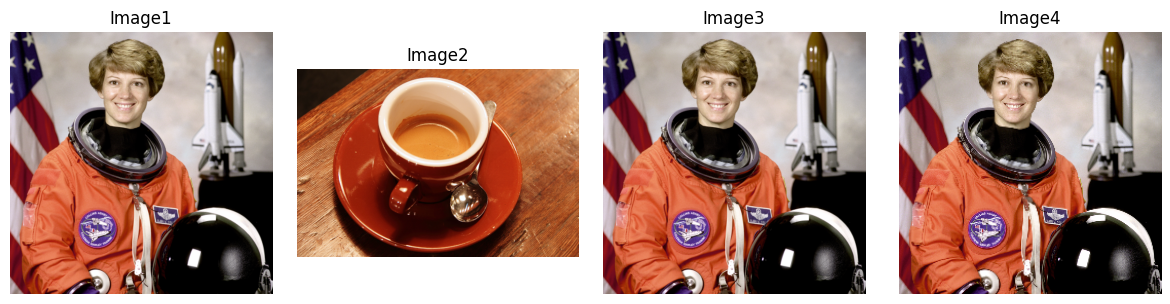

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte
from scipy.spatial import distance

# Fungsi untuk menghitung histogram RGB gabungan
def calculate_rgb_histogram(image, bins=16):
    img_uint8 = img_as_ubyte(image)
    hist_r, _ = np.histogram(img_uint8[:,:,0].ravel(), bins=bins, range=(0,256))
    hist_g, _ = np.histogram(img_uint8[:,:,1].ravel(), bins=bins, range=(0,256))
    hist_b, _ = np.histogram(img_uint8[:,:,2].ravel(), bins=bins, range=(0,256))
    hist_combined = np.concatenate((hist_r, hist_g, hist_b)).astype(float)
    s = hist_combined.sum()
    if s>0:
        hist_combined /= s
    return hist_combined

# 1. Muat citra
image1 = data.astronaut()
image2 = data.coffee()
image3 = data.astronaut()
image4 = image1[::2, ::2, :]

# 2. Hitung histogram
hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)
hist4 = calculate_rgb_histogram(image4)

# 3. Hitung Cosine Similarity
sim_12 = 1 - distance.cosine(hist1, hist2)
sim_13 = 1 - distance.cosine(hist1, hist3)
sim_14 = 1 - distance.cosine(hist1, hist4)

print(f"Cosine Similarity (1 vs 2): {sim_12:.4f}")
print(f"Cosine Similarity (1 vs 3 - identical): {sim_13:.4f}")
print(f"Cosine Similarity (1 vs 4 - downsampled): {sim_14:.4f}")

# Visualisasi sederhana
fig, axes = plt.subplots(1,4, figsize=(12,3))
axes[0].imshow(image1); axes[0].set_title('Image1'); axes[0].axis('off')
axes[1].imshow(image2); axes[1].set_title('Image2'); axes[1].axis('off')
axes[2].imshow(image3); axes[2].set_title('Image3'); axes[2].axis('off')
axes[3].imshow(image4); axes[3].set_title('Image4'); axes[3].axis('off')
plt.tight_layout(); plt.show()

Tugas Lanjutan:
Amati nilai Cosine Similarity. Apakah nilai untuk citra yang identik (Image 1 & 3) mendekati 1? Bagaimana kemiripan antara citra yang berbeda (Image 1 & 2)? Bagaimana kemiripan antara citra asli dan versi downsampled-nya (Image 1 & 4) berdasarkan histogram?